# 03 — Logistic Regression

This notebook implements an **interpretable logistic regression model** for heart disease prediction. Logistic regression serves as the **primary modelling approach** in this study because it is well suited for binary outcomes and allows the contribution of individual predictors to be interpreted directly through model coefficients.

The model is used to estimate the probability of heart disease based on clinical and demographic characteristics. These predicted probabilities form the basis for the final **probability-based risk score**.

To reduce the risk of overfitting and identify the most relevant predictors, **L1-regularized logistic regression (LASSO)** is applied. This allows less informative coefficients to shrink towards zero and supports a more interpretable final model.

A **gradient boosting classifier** is implemented separately in **04_gradient_boosting.ipynb** as a benchmark model. This enables us to assess whether a more flexible non-linear approach provides meaningfully better predictive performance than the interpretable logistic regression model.

## Focus: Minimising False Negatives

Since the model is intended as a **medical screening tool**, the most critical error is a **false negative** — predicting "no disease" when a patient actually has heart disease.

We therefore analyse multiple classification thresholds to identify a threshold that reduces false negatives while maintaining acceptable overall model performance. This prioritises detecting potentially diseased patients, even at the cost of more false positives.

## Model Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| penalty | L1 | Enables feature selection via LASSO |
| solver | liblinear | Supports L1 regularization |
| max_iter | 1000 | Ensures convergence |

## Setup

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
    plot_roc_curve, classification_report_df,
)

FIGURES = "../results/figures"
TABLES  = "../results/tables"
MODELS  = "../results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue  (LogReg primary)
CLR_RED   = "#CA6B6E"   # muted rose
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "pres_blue", [CLR_GRAY, CLR_BLUE], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_BLUE,
    "axes.labelcolor": CLR_BLUE,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_BLUE,
    "xtick.color": CLR_BLUE,
    "ytick.color": CLR_BLUE,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 1 — Data Loading & Preparation
We load the processed dataset produced in the preprocessing step. The dataset includes all clinical predictors as well as `source_code` (hospital origin). Before training the logistic regression model, we briefly verify the dataset structure and target distribution.

### Load dataset

In [2]:
df = load_processed_data()

print(f"Shape: {df.shape}")
print(f"NaN values: {df.isna().sum().sum()}")

print("\nTarget distribution:")
print(df["num"].value_counts().sort_index())


Shape: (920, 14)
NaN values: 0

Target distribution:
num
0    411
1    509
Name: count, dtype: int64


### Feature / Target split

In [3]:
# Single variant: full_source (all clinical features + hospital origin)
X, y = get_feature_target_split(df, drop_source=False, drop_high_missing=False)
groups = get_column_groups(X)
print(f"Features: {X.shape[1]}  "
      f"(cont={len(groups['continuous'])}, bin={len(groups['binary'])}, multi={len(groups['multiclass'])})")
print(f"Columns: {list(X.columns)}")


Features: 13  (cont=5, bin=3, multi=5)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal', 'source_code']


### Train / Test Split

In [4]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} samples  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})")
print(f"Test:  {len(X_test)} samples  (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")


Train: 736 samples  (pos=407, neg=329)
Test:  184 samples  (pos=102, neg=82)


## 2 — Model Training & Cross-Validation

We build a single pipeline (**ColumnTransformer → LogisticRegression**) as the primary modelling approach for heart disease prediction. Logistic regression is well suited for this task because the outcome is binary and the model remains interpretable through its coefficients.

To reduce overfitting and support feature selection, we use **L1-regularized logistic regression (LASSO)**. L1 regularization shrinks less informative coefficients towards zero and can therefore remove predictors from the final model. This is particularly useful for a moderate-sized dataset like ours, where a simpler model is preferable both for robustness and interpretability.

We evaluate the model using **5-fold cross-validation** on the training set before fitting it to the full training data. Cross-validation provides an estimate of generalisation performance and helps assess whether the model is stable across different data splits.

Important distinction — regularization vs. cross-validation: These are two separate mechanisms operating at different levels.
- `penalty="l1"` works *inside* the model: it regularises the coefficient estimates and shrinks weak predictors towards zero. It improves parsimony and interpretability.
- Cross-validation (5-fold CV) works *outside* the model: it repeatedly splits the training set into folds, trains the model on 4 folds, and evaluates it on the held-out fold. It produces the `CV ROC-AUC` score we report below.

In short: regularization helps keep the model simple; cross-validation tells us how well it generalises.

### Model Pipeline Definition

In [5]:
# Logistic regression model
LOGREG_PARAMS = dict(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

# Build pipeline
preprocessor = build_preprocessor(groups)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(**LOGREG_PARAMS)),
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold:   {np.round(cv_scores, 4)}")

# Fit on full training set
pipe.fit(X_train, y_train)

# Predict probabilities on test set
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC:  {test_auc:.4f}")
print(f"\nClassification report (default threshold = 0.5):")
print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))


CV ROC-AUC: 0.8974 ± 0.0276
Per fold:   [0.8816 0.8604 0.9364 0.8874 0.9214]

Test ROC-AUC:  0.9096

Classification report (default threshold = 0.5):
              precision    recall  f1-score   support

  No Disease       0.85      0.80      0.82        82
     Disease       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



## 3 — Threshold Optimisation

The default classification threshold of 0.5 may not be optimal for medical screening tasks. 
In our context, the most critical error is a **false negative** — predicting "no disease" when a patient actually has heart disease.

Since this model could be used as an initial screening tool, the cost of errors is asymmetric:

- **False positives** are acceptable: they only lead to an additional medical examination.
- **False negatives** are critical: a patient with heart disease might remain undiagnosed.

We therefore analyse different classification thresholds based on predicted probabilities to evaluate how recall (sensitivity) and specificity change. This helps identify thresholds that reduce false negatives while maintaining reasonable overall performance.

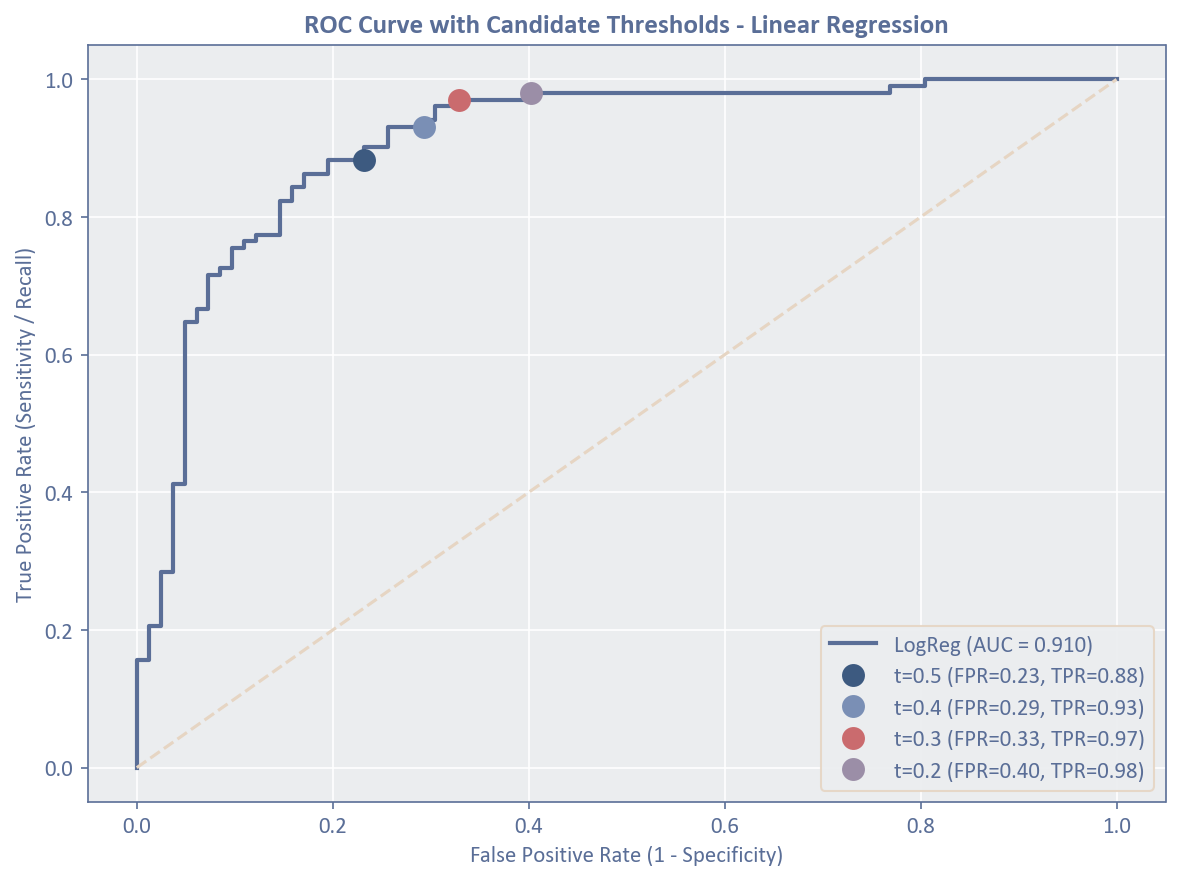

,threshold,precision,recall,f1,accuracy,specificity
0,0.5,0.849057,0.882353,0.865385,0.847826,0.804878
1,0.4,0.805085,0.931373,0.863636,0.836957,0.719512
2,0.3,0.779528,0.970588,0.864629,0.831522,0.658537
3,0.2,0.735294,0.980392,0.840336,0.793478,0.560976


In [16]:
# ROC curve with candidate thresholds marked
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Candidate thresholds to compare
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=CLR_BLUE, lw=2, label=f"LogReg (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark candidate thresholds on the ROC curve
marker_colors = ["#3D5A80", "#7A8FB5", "#CA6B6E", "#9B8EA7"]
for thresh, color in zip(candidate_thresholds, marker_colors):
    idx = np.argmin(np.abs(thresholds - thresh))
    ax.plot(
        fpr[idx], tpr[idx], "o",
        color=color, markersize=10,
        label=f"t={thresh:.1f} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})"
    )

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve with Candidate Thresholds - Linear Regression")
ax.legend(loc="lower right")

fig.savefig(f"{FIGURES}/logreg_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

threshold_results = []

for thresh in candidate_thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    threshold_results.append({
        "threshold": thresh,
        "precision": precision_score(y_test, y_pred_thresh),
        "recall": recall_score(y_test, y_pred_thresh),
        "f1": f1_score(y_test, y_pred_thresh),
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "specificity": confusion_matrix(y_test, y_pred_thresh)[0, 0] /
                       confusion_matrix(y_test, y_pred_thresh)[0].sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

## 4 — Confusion Matrices at Different Thresholds

We compare several thresholds to better understand the trade-off between false negatives and false positives. For each threshold, we visualise the confusion matrix and compute key performance metrics.

In this medical screening context, the most critical error is the **false negative (FN)** — a patient with heart disease who is predicted as "No Disease". Reducing FN is therefore a central objective when selecting the classification threshold.

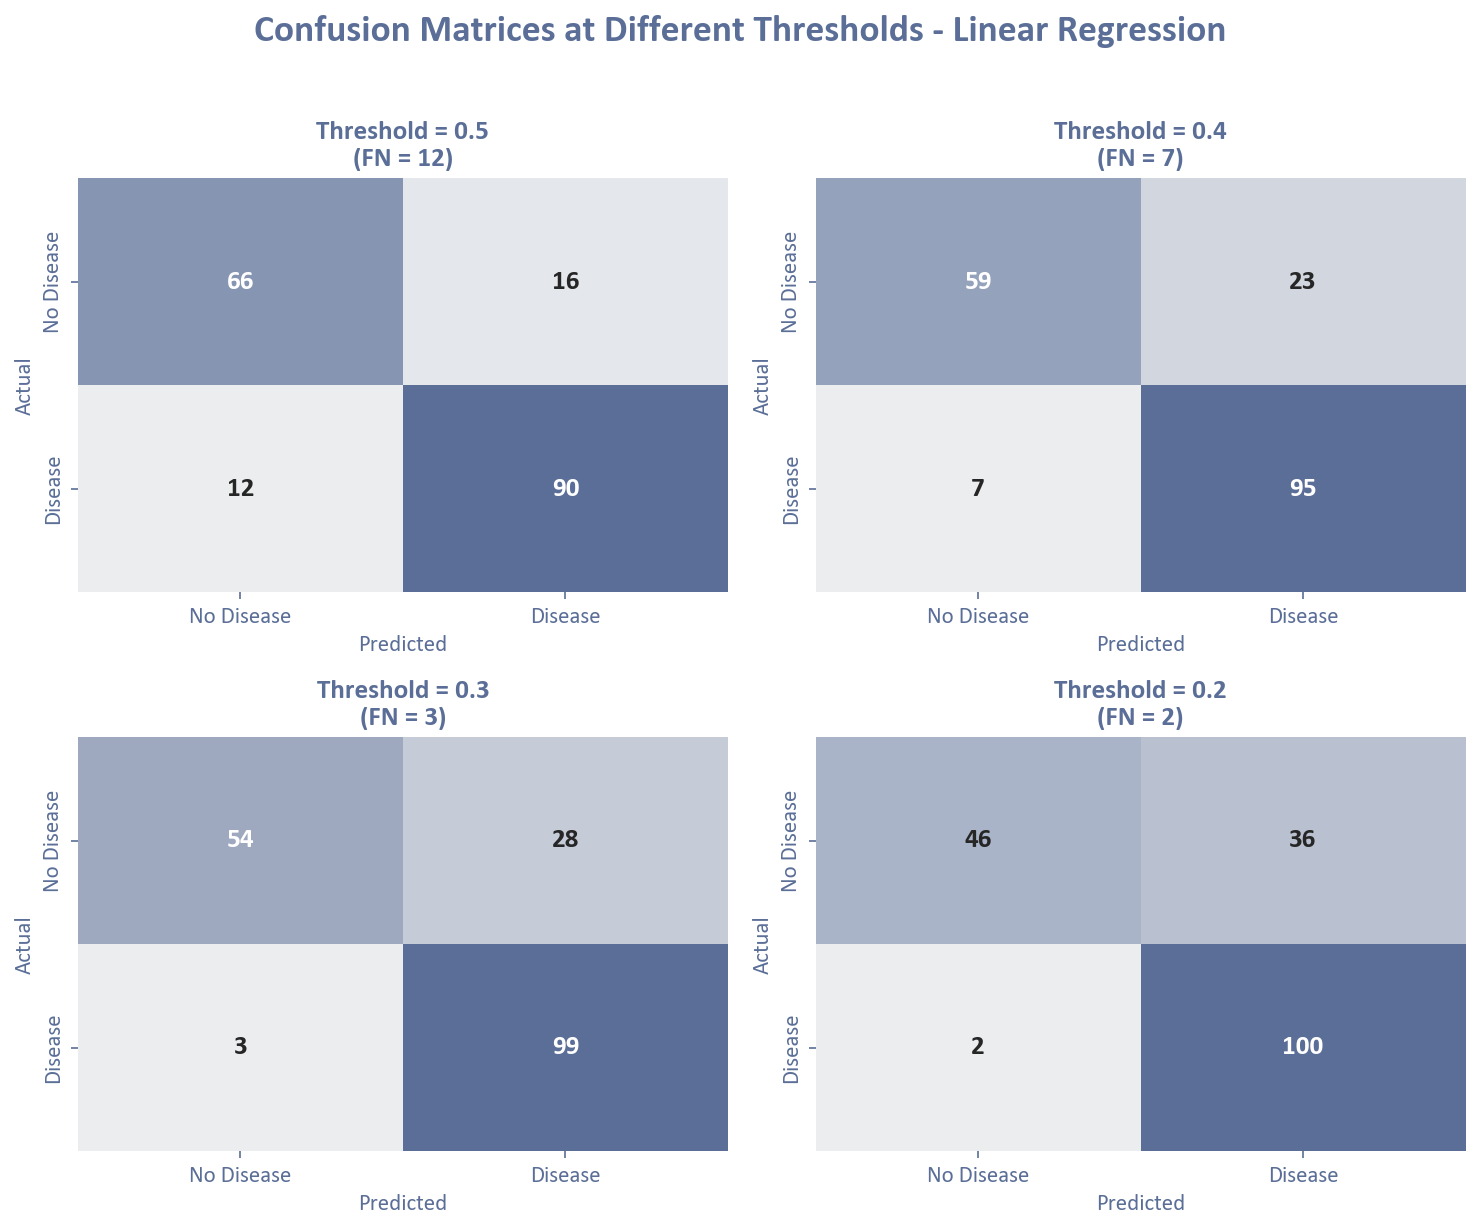

In [15]:
# Confusion matrices in 2x2 grid for all candidate thresholds
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, thresh in enumerate(candidate_thresholds):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=CMAP_BLUE,
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"],
        ax=axes[i],
        cbar=False,
        annot_kws={"fontsize": 13, "fontweight": "bold"},
    )

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].grid(False)

    fn = cm[1, 0]  # actual=Disease, predicted=No Disease
    axes[i].set_title(f"Threshold = {thresh}\n(FN = {fn})")

fig.suptitle("Confusion Matrices at Different Thresholds - Linear Regression", fontsize=18, y=1.02, fontweight="bold")
fig.savefig(f"{FIGURES}/logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [8]:
# Detailed metrics comparison across thresholds
rows = []

for thresh in candidate_thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "Threshold": thresh,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred_t),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_test, y_pred_t),
        "FN Rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(f"{TABLES}/logreg_threshold_comparison.csv", index=False)

print("Threshold comparison (FN = missed disease cases):\n")
threshold_df.round(4)


Threshold comparison (FN = missed disease cases):



,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall (Sensitivity),Specificity,F1,FN Rate
0,0.5,90,16,12,66,0.8478,0.8491,0.8824,0.8049,0.8654,0.1176
1,0.4,95,23,7,59,0.8370,0.8051,0.9314,0.7195,0.8636,0.0686
2,0.3,99,28,3,54,0.8315,0.7795,0.9706,0.6585,0.8646,0.0294
3,0.2,100,36,2,46,0.7935,0.7353,0.9804,0.5610,0.8403,0.0196


### Threshold Selection Rationale

The confusion matrices and performance metrics clearly illustrate the trade-off between false negatives and false positives when lowering the classification threshold.

At the default threshold of **0.5**, the model achieves balanced performance with an accuracy of **0.85** and a recall of **0.88**, but still misses **12 disease cases** (FN). For a medical screening tool, this number of missed cases may be considered too high.

Lowering the threshold reduces the number of false negatives substantially. At **0.4**, recall increases to **0.93**, reducing missed disease cases from **12 to 7**, while specificity remains at a reasonable **0.72**.

At **0.3**, recall further increases to **0.97**, meaning that only **3 disease cases are missed**. Although specificity decreases to **0.66**, the model still correctly identifies roughly two thirds of healthy patients.

Reducing the threshold further to **0.2** only marginally improves recall (FN = 2), but leads to a much larger increase in false positives and a noticeable drop in specificity (**0.56**).

Considering the clinical context — where missing a disease case is far more critical than sending a healthy patient for an additional examination — a threshold of **0.3** represents a reasonable compromise. It achieves very high recall while maintaining acceptable specificity and overall model stability.

## 5 — Coefficient Interpretation & Odds Ratios

One key advantage of logistic regression is its interpretability. Each model coefficient indicates how a predictor influences the log-odds of the outcome. By exponentiating the coefficients, we obtain **odds ratios**, which are easier to interpret.

An odds ratio greater than 1 indicates that higher values of the predictor increase the probability of heart disease, while an odds ratio below 1 indicates a protective effect.

Because the preprocessing pipeline standardises continuous variables and one-hot encodes categorical variables, coefficients correspond to the transformed feature space. For standardised variables, the effect corresponds to a change of one standard deviation.

In [9]:
# Extract trained components from pipeline
preprocessor_fitted = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

# Extract coefficients
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()


,feature,coefficient
0,age,0.251582
1,trestbps,0.030022
2,chol,0.217112
3,thalach,-0.227891
4,oldpeak,0.574286


In [10]:
# Convert logistic regression coefficients to odds ratios and sort features by effect size
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df = coef_df.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

print("Top predictors increasing disease risk:\n")
coef_df.head(10)


Top predictors increasing disease risk:



,feature,coefficient,odds_ratio
0,source_code_4,2.842936,17.166092
1,sex,1.135179,3.111731
2,thal_7.0,1.027209,2.793259
3,cp_4.0,0.875518,2.400119
4,exang,0.864332,2.373421
5,slope_2.0,0.655368,1.925850
6,oldpeak,0.574286,1.775862
7,thal_6.0,0.465635,1.593025
8,source_code_3,0.377070,1.458006
9,fbs,0.349983,1.419043


In [11]:
# Show features with the lowest odds ratios (strongest protective effects)
print("Top predictors decreasing disease risk:\n")
coef_df.sort_values("odds_ratio").head(10)


Top predictors decreasing disease risk:



,feature,coefficient,odds_ratio
19,cp_2.0,-1.038870,0.353854
18,thalach,-0.227891,0.796211
17,cp_3.0,-0.165143,0.847772
16,source_code_2,-0.095432,0.908980
15,restecg_2.0,0.000000,1.000000
14,slope_3.0,0.000000,1.000000
13,trestbps,0.030022,1.030477
12,restecg_1.0,0.093524,1.098037
11,chol,0.217112,1.242483
10,age,0.251582,1.286058


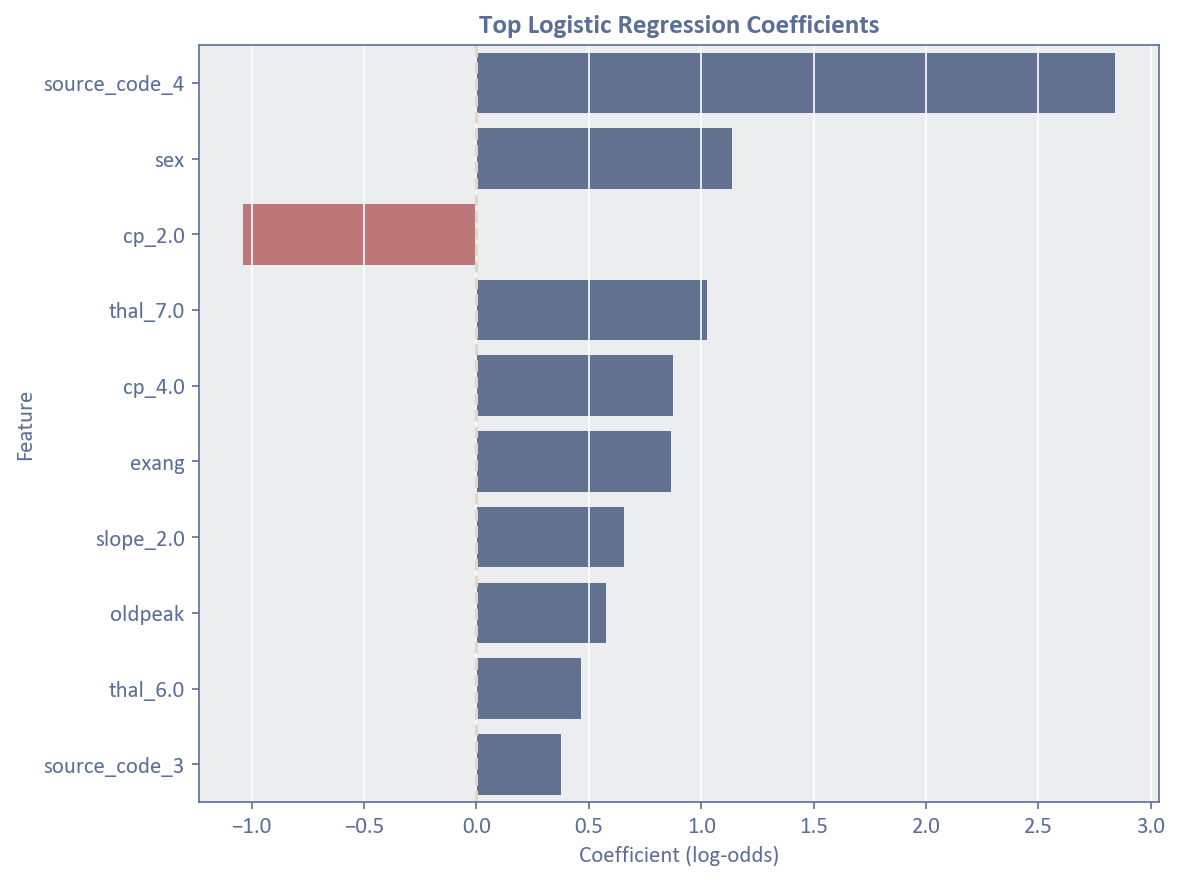

In [12]:
# Plot top coefficients
top = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [CLR_RED if v < 0 else CLR_BLUE for v in top["coefficient"]]
sns.barplot(
    data=top,
    y="feature",
    x="coefficient",
    palette=colors,
    ax=ax,
)

ax.axvline(0, color=CLR_BEIGE, linestyle="--", lw=1.5)
ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Coefficient (log-odds)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(f"{FIGURES}/logreg_coefficients.png", dpi=150)
plt.show()

In [13]:
# Aggregate coefficients from one-hot encoded features back to their original variables
_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

original_importance = {}

for row in coef_df.itertuples():
    col = row.feature
    coef = abs(row.coefficient)

    original = col

    if col.startswith("source_"):
        original = "source_code"
    else:
        for name in _MULTICLASS_ORIGINALS:
            if col.startswith(name + "_"):
                original = name
                break

    if original not in original_importance:
        original_importance[original] = 0

    original_importance[original] += coef


importance_df = (
    pd.DataFrame(list(original_importance.items()), columns=["feature", "importance"])
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["rank"] = range(1, len(importance_df)+1)

importance_df


,feature,importance,rank
0,source_code,3.315438,1
1,cp,2.079532,2
2,thal,1.492844,3
3,sex,1.135179,4
4,exang,0.864332,5
5,slope,0.655368,6
6,oldpeak,0.574286,7
7,fbs,0.349983,8
8,age,0.251582,9
9,thalach,0.227891,10


## 6 - Critical disussion

## 7 - Final summary & saved artifacts

## 8 - Outlook & future steps